In [85]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

In [86]:
data = []
labels = []
file_name = []

IMG_SIZE = (128, 128)

for sub_folder in os.listdir("Assets"):
    sub_folder_files = os.listdir(os.path.join("Assets", sub_folder))
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join("Assets", sub_folder, filename)
        img = cv.imread(img_path)

        if img is None:
            continue

        data.append(img)
        labels.append(sub_folder)
        file_name.append(f"{sub_folder}_{i+1}.jpg")

print(f"Total data: {len(data)}")
print(f"Kelas: {sorted(set(labels))}")

Total data: 450
Kelas: ['Cassava___bacterial_blight', 'Cassava___brown_streak_disease', 'Cassava___green_mottle', 'Cassava___healthy', 'Cassava___mosaic_disease']


In [103]:
def median_filter(img, size):
    h, w = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    
    area = size * size
    target = area // 2 
    
    for i in range(h):
        for j in range(w):
            region = padded[i:i+size, j:j+size]
            
            counts = [0] * 256
            for row in region:
                for val in row:
                    counts[int(val)] += 1
            
            current_sum = 0
            for val in range(256):
                current_sum += counts[val]
                if current_sum > target:
                    canvas[i, j] = val
                    break
    return canvas

kernel = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 1, 0]
], dtype=np.uint8)

In [88]:
size = (128, 128)
# P2 : Resize → Grayscale → Median Filter → Morfologi Opening
def pre_proses(image, target_size=size):
    resized = cv.resize(image, target_size)
    
    if len(resized.shape) == 3:
        gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray = resized

    img = median_filter(gray, 3)
    img = cv.morphologyEx(img, cv.MORPH_OPEN, kernel)

    return img

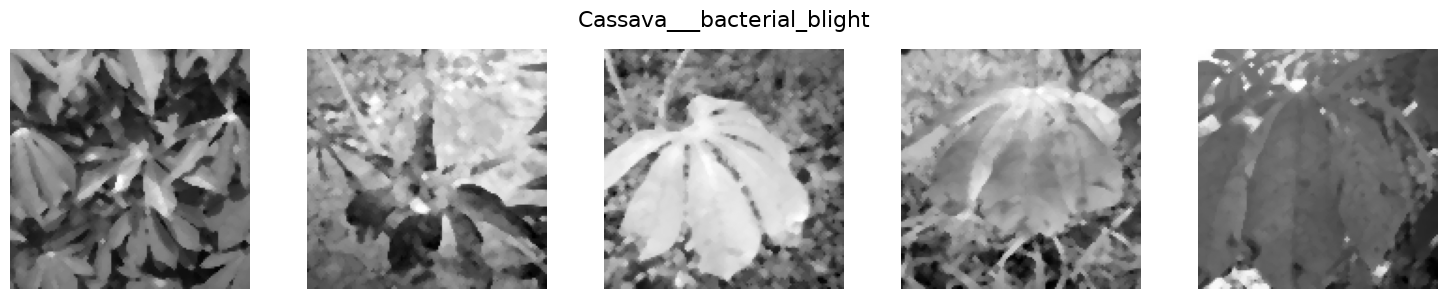

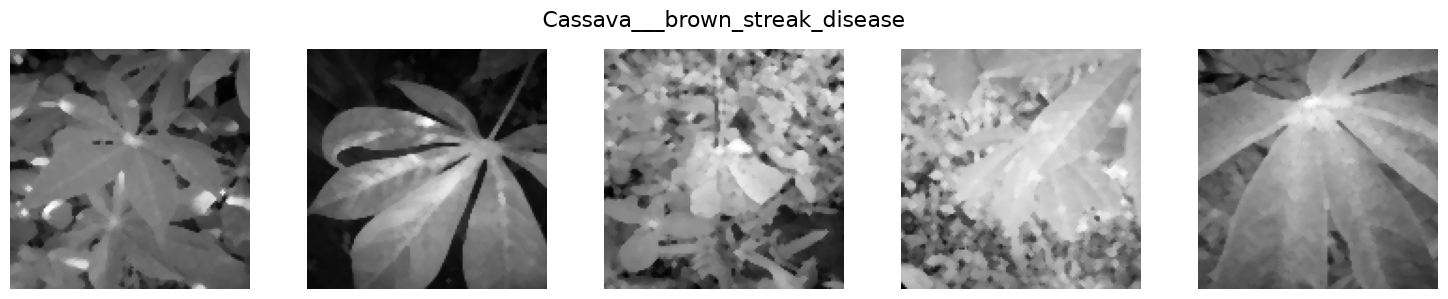

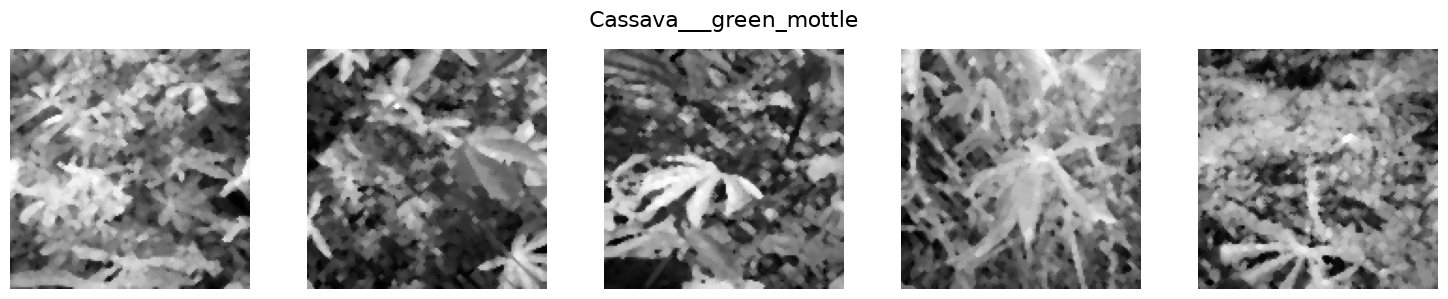

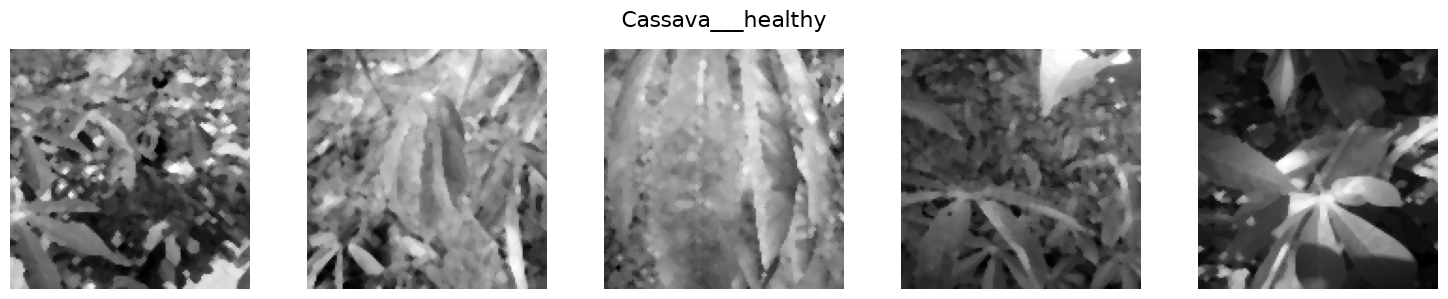

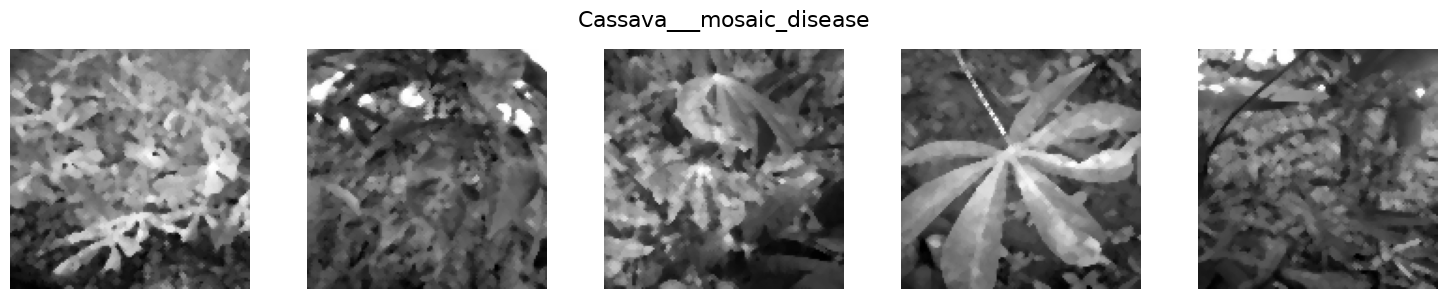

In [89]:
def percobaan2(img):
    hasil = pre_proses(img)
    return hasil

dataPreprocessed = [percobaan2(img) for img in data]
unique_labels = sorted(set(labels))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]
    fig, axs = plt.subplots(1, 5, figsize=(15, 3)) 
    fig.suptitle(label, fontsize=16)

    for k in range(5):
        ax = axs[k]
        
        if k < len(idxs):
            ax.imshow(dataPreprocessed[idxs[k]], cmap='gray')

        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

In [104]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm = graycomatrix(image.astype(np.uint8), [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [105]:
def correlation_feat(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [106]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(dataPreprocessed)):
    D0   = glcm(dataPreprocessed[i], 0)
    D45  = glcm(dataPreprocessed[i], 45)
    D90  = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135         = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135         = [], [], [], []
ASM0, ASM45, ASM90, ASM135                         = [], [], [], []
energy0, energy45, energy90, energy135             = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

    correlation0.append(correlation_feat(Derajat0[i]))
    correlation45.append(correlation_feat(Derajat45[i]))
    correlation90.append(correlation_feat(Derajat90[i]))
    correlation135.append(correlation_feat(Derajat135[i]))

print(f"Ekstraksi fitur selesai untuk {len(dataPreprocessed)} citra.")

Ekstraksi fitur selesai untuk 450 citra.


In [107]:
dataTable = {
    'Filename': file_name, 'Label': labels,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}
df = pd.DataFrame(dataTable)
df.to_csv('./Hasil_ekstraksi/hasil_ekstraksi_Percobaan2.csv', index=False)

hasilEkstrak = pd.read_csv('./Hasil_ekstraksi/hasil_ekstraksi_Percobaan2.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,Cassava___bacterial_blight_1.jpg,Cassava___bacterial_blight,311.409941,466.291029,282.004921,433.715667,0.315722,0.311429,0.337085,0.303867,...,0.000660,0.000568,0.024104,0.024148,0.025682,0.023827,0.907989,0.862518,0.916607,0.872118
1,Cassava___bacterial_blight_2.jpg,Cassava___bacterial_blight,157.464013,240.302685,179.652375,288.289789,0.358611,0.340178,0.345693,0.323785,...,0.000735,0.000682,0.027827,0.027422,0.027104,0.026110,0.949619,0.923150,0.942576,0.907794
2,Cassava___bacterial_blight_3.jpg,Cassava___bacterial_blight,232.951280,401.957840,250.087721,354.951764,0.353972,0.336828,0.357896,0.329277,...,0.000966,0.000819,0.030399,0.029749,0.031077,0.028625,0.954287,0.920886,0.950939,0.930141
3,Cassava___bacterial_blight_4.jpg,Cassava___bacterial_blight,200.626292,329.727199,208.929688,283.917974,0.335767,0.305633,0.329490,0.329524,...,0.000755,0.000788,0.027627,0.026188,0.027476,0.028073,0.932723,0.889046,0.929924,0.904460
4,Cassava___bacterial_blight_5.jpg,Cassava___bacterial_blight,168.998339,296.621303,187.046567,222.352905,0.421627,0.399826,0.445905,0.409282,...,0.002357,0.002055,0.045957,0.044265,0.048551,0.045331,0.930795,0.876182,0.922456,0.907123
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,Cassava___mosaic_disease_86.jpg,Cassava___mosaic_disease,200.597318,497.048112,372.615219,386.752868,0.362035,0.312369,0.325975,0.342959,...,0.000695,0.000768,0.028814,0.025874,0.026370,0.027714,0.960574,0.901416,0.925998,0.923287
446,Cassava___mosaic_disease_87.jpg,Cassava___mosaic_disease,292.410925,479.420857,310.258428,454.796888,0.357568,0.318429,0.329603,0.321099,...,0.000678,0.000671,0.028478,0.025459,0.026039,0.025903,0.928313,0.882078,0.923753,0.888133
447,Cassava___mosaic_disease_88.jpg,Cassava___mosaic_disease,245.112820,374.832538,263.501969,394.991506,0.316877,0.304791,0.311717,0.310493,...,0.000574,0.000604,0.024425,0.024081,0.023956,0.024571,0.937422,0.903740,0.932397,0.898568
448,Cassava___mosaic_disease_89.jpg,Cassava___mosaic_disease,193.875861,312.223386,207.938792,289.381425,0.324762,0.302944,0.312786,0.310398,...,0.000624,0.000644,0.025777,0.024907,0.024978,0.025379,0.937019,0.898229,0.932282,0.905665


Fitur sebelum seleksi: 28
Fitur setelah seleksi: 16
Fitur terpilih        : ['Contrast0', 'Contrast45', 'Contrast90', 'Contrast135', 'Homogeneity0', 'Homogeneity45', 'Homogeneity90', 'Homogeneity135', 'Dissimilarity0', 'Entropy0', 'ASM0', 'Energy0', 'Correlation0', 'Correlation45', 'Correlation90', 'Correlation135']


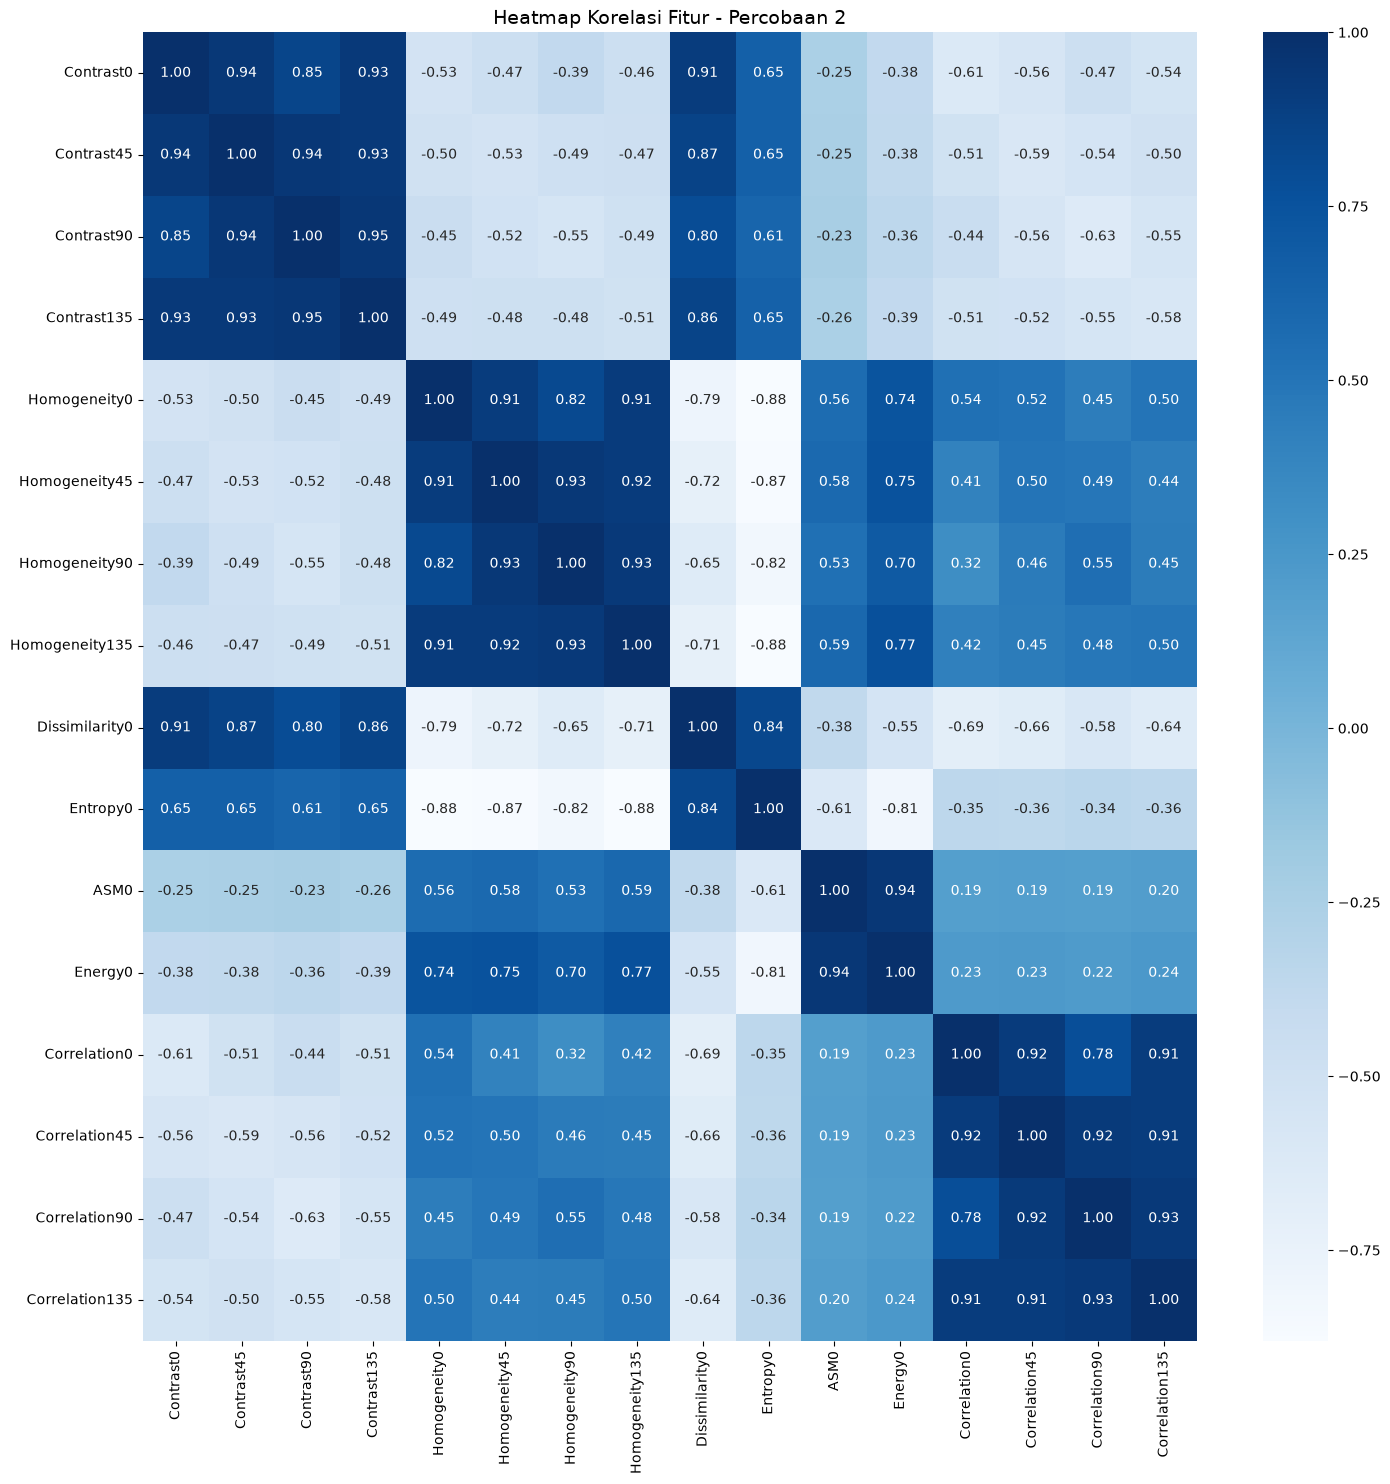

In [108]:
corr_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((corr_matrix.shape[0],), True, dtype=bool)
for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[0]):
        if abs(corr_matrix.iloc[i,j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"Fitur sebelum seleksi: {len(hasilEkstrak.columns) - 2}")
print(f"Fitur setelah seleksi: {len(select)}")
print(f"Fitur terpilih        : {list(select)}")

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap Korelasi Fitur - Percobaan 2', fontsize=14)
plt.show()

In [109]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (360, 16)
X_test shape:  (90, 16)


In [110]:
mean_train = X_train.mean()
std_train  = X_train.std()

X_test  = (X_test  - mean_train) / std_train
X_train = (X_train - mean_train) / std_train

In [111]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))
    
rf  = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

In [112]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport(y_test, y_pred)

------Training Set------
                                precision    recall  f1-score   support

    Cassava___bacterial_blight       0.84      0.95      0.89        66
Cassava___brown_streak_disease       0.89      0.87      0.88        75
        Cassava___green_mottle       0.88      0.94      0.91        78
             Cassava___healthy       0.94      0.89      0.92        73
      Cassava___mosaic_disease       0.98      0.87      0.92        68

                      accuracy                           0.90       360
                     macro avg       0.91      0.90      0.90       360
                  weighted avg       0.91      0.90      0.90       360

[[63  2  0  1  0]
 [ 5 65  4  0  1]
 [ 3  0 73  2  0]
 [ 3  4  1 65  0]
 [ 1  2  5  1 59]]
Accuracy: 0.9027777777777778

------Testing Set------
                                precision    recall  f1-score   support

    Cassava___bacterial_blight       0.41      0.38      0.39        24
Cassava___brown_streak_disease    

In [113]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
                                precision    recall  f1-score   support

    Cassava___bacterial_blight       0.47      0.29      0.36        66
Cassava___brown_streak_disease       0.43      0.60      0.50        75
        Cassava___green_mottle       0.45      0.32      0.38        78
             Cassava___healthy       0.46      0.41      0.43        73
      Cassava___mosaic_disease       0.46      0.65      0.54        68

                      accuracy                           0.45       360
                     macro avg       0.46      0.45      0.44       360
                  weighted avg       0.46      0.45      0.44       360

[[19 20  9 12  6]
 [ 3 45  6 12  9]
 [ 7 14 25  9 23]
 [ 7 15  8 30 13]
 [ 4 11  7  2 44]]
Accuracy: 0.4527777777777778

------Testing Set------
                                precision    recall  f1-score   support

    Cassava___bacterial_blight       0.38      0.21      0.27        24
Cassava___brown_streak_disease   

In [114]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
                                precision    recall  f1-score   support

    Cassava___bacterial_blight       0.44      0.52      0.48        66
Cassava___brown_streak_disease       0.55      0.60      0.57        75
        Cassava___green_mottle       0.45      0.49      0.47        78
             Cassava___healthy       0.55      0.33      0.41        73
      Cassava___mosaic_disease       0.57      0.60      0.59        68

                      accuracy                           0.51       360
                     macro avg       0.51      0.51      0.50       360
                  weighted avg       0.51      0.51      0.50       360

[[34 10  8  8  6]
 [14 45  6  4  6]
 [11 11 38  4 14]
 [13 13 18 24  5]
 [ 5  3 15  4 41]]
Accuracy: 0.5055555555555555

------Testing Set------
                                precision    recall  f1-score   support

    Cassava___bacterial_blight       0.40      0.42      0.41        24
Cassava___brown_streak_disease   

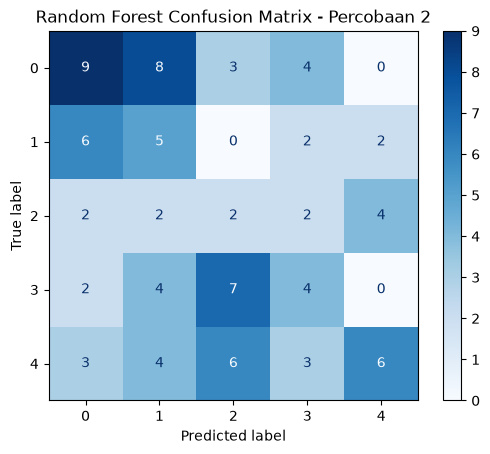

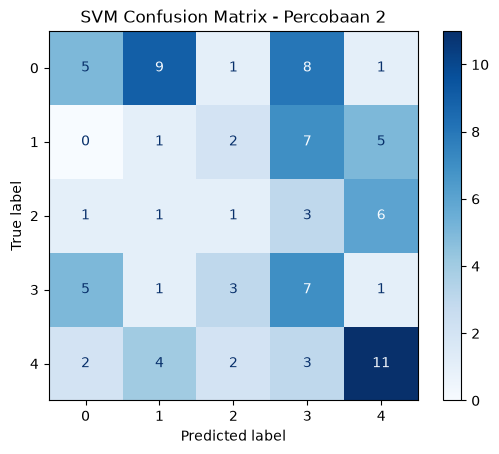

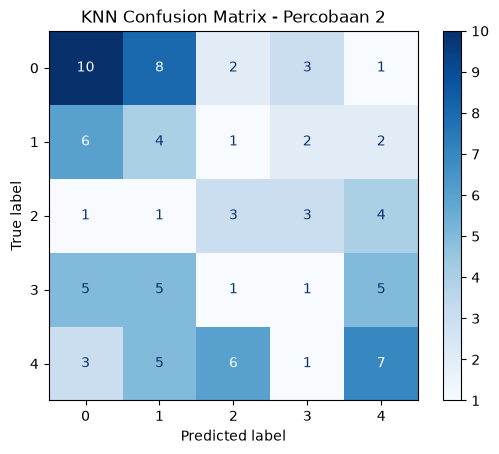

In [115]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test),  "Random Forest Confusion Matrix - Percobaan 2")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix - Percobaan 2")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix - Percobaan 2")

In [116]:
# Simpan hasil perbandingan model
hasil_klasifikasi = {
    'Model'    : ['Random Forest', 'SVM', 'KNN'],
    'Accuracy_Train': [
        accuracy_score(y_train, rf.predict(X_train)),
        accuracy_score(y_train, svm.predict(X_train)),
        accuracy_score(y_train, knn.predict(X_train)),
    ],
    'Accuracy_Test': [
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, svm.predict(X_test)),
        accuracy_score(y_test, knn.predict(X_test)),
    ],
    'Precision': [
        precision_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        precision_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        precision_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'Recall': [
        recall_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        recall_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        recall_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'F1_Score': [
        f1_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        f1_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        f1_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
}
df_hasil = pd.DataFrame(hasil_klasifikasi)
df_hasil.to_csv('./Hasil_klasifikasi/hasil_klasifikasi_Percobaan2.csv', index=False)
df_hasil

,Model,Accuracy_Train,Accuracy_Test,Precision,Recall,F1_Score
0,Random Forest,0.902778,0.288889,0.332730,0.288889,0.299482
1,SVM,0.452778,0.277778,0.287055,0.277778,0.271197
2,KNN,0.505556,0.277778,0.275369,0.277778,0.273392
